# **Feature engineering**

## Table of contents

[Loading data](#Loading-data)

- [age](#age)
- [MonthlyIncome](#MonthlyIncome)
- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [DebtRatio](#DebtRatio)
- [NumberOfDependents](#NumberOfDependents)
- [NumberOfOpenCreditLinesAndLoans](#NumberOfOpenCreditLinesAndLoans)
- [NumberRealEstateLoansOrLines](#NumberRealEstateLoansOrLines)
- [NumberOfTime30-59DaysPastDueNotWorse](#NumberOfTime30-59DaysPastDueNotWorse)
- [NumberOfTime60-89DaysPastDueNotWorse](#NumberOfTime60-89DaysPastDueNotWorse)
- [NumberOfTimes90DaysLate](#NumberOfTimes90DaysLate)

## Loading data

In [9]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from optbinning import OptimalBinning

from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import scale, robust_scale, power_transform

from src import get_config, set_seeds, create_preprocessing_pipeline, \
                plot_feature_analysis, plot_WoE, WoEConfig

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
config = get_config()

train_raw = pd.read_csv(config.paths.train_file).drop(columns=['Unnamed: 0'])
print(f"Data shape: {train_raw.shape}")

X = train_raw.drop(columns=[config.data.target_col])
y = train_raw[config.data.target_col]

Data shape: (150000, 11)


## Preprocessing

### Normal

In [3]:
pipeline = create_preprocessing_pipeline(config)

print("Pipeline Steps:")
for step_name, transformer in pipeline.steps:
    print(f" - {step_name}: {transformer}")

Pipeline Steps:
 - clipper: OutlierClipper(config=OutlierClippingConfig(age_bounds=(21, 87),
                                            debt_ratio_upper=2.0,
                                            utilization_upper=1.5,
                                            income_upper_percentile=99.0))
 - imputer: CustomImputer(config=ImputationConfig(income_strategy='median',
                                      dependents_strategy='constant',
                                      constant_fill_value=0.0))
 - feature_adder: FeatureAdder(config=FeatureCreationConfig(add_age_buckets=True,
                                          add_debt_income_ratio=True,
                                          add_utilization_squared=True,
                                          add_delinquency_features=True,
                                          age_young_threshold=30,
                                          age_senior_threshold=60))
 - scaler: StandardScaler()


In [4]:
X_processed = pipeline.fit_transform(X, y)

feature_names = pipeline[-1].get_feature_names_out()

train_processed = pd.DataFrame(X_processed, columns=feature_names)
train_processed.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_young,is_senior,debt_income_ratio,utilization_squared,total_delinquencies,has_delinquency
count,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,-9.417060e-17,-1.466560e-16,9.663381e-18,-1.918465e-16,2.756906e-17,8.299139e-17,1.155816e-17,-2.330580e-17,1.184238e-17,-5.153803e-17,-3.789561e-18,-5.153803e-17,1.002339e-16,4.244309e-17,1.989520e-17,2.842171e-18
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-9.004574e-01,-2.127567e+00,-1.004190e-01,-9.440205e-01,-1.571321e+00,-1.642610e+00,-6.379344e-02,-9.012830e-01,-5.785249e-02,-6.661260e-01,-2.499619e-01,-6.893383e-01,-9.370479e-01,-6.230098e-01,-7.439285e-02,-5.037784e-01
25%,-8.171748e-01,-7.666002e-01,-1.004190e-01,-7.018363e-01,-5.758862e-01,-6.709686e-01,-6.379344e-02,-9.012830e-01,-5.785249e-02,-6.661260e-01,-2.499619e-01,-6.893383e-01,-7.410599e-01,-6.206234e-01,-7.439285e-02,-5.037784e-01
50%,-4.705384e-01,-1.806820e-02,-1.004190e-01,-4.370205e-01,-1.940861e-01,-8.798403e-02,-6.379344e-02,-1.614492e-02,-5.785249e-02,-6.661260e-01,-2.499619e-01,-6.893383e-01,-3.980694e-01,-5.594193e-01,-7.439285e-02,-5.037784e-01
75%,6.583924e-01,7.304638e-01,-1.004190e-01,2.570578e-01,3.160010e-01,4.950005e-01,-6.379344e-02,8.689932e-01,-5.785249e-02,2.372019e-01,-2.499619e-01,1.450666e+00,2.873157e-01,2.130306e-01,-7.439285e-02,-5.037784e-01
max,3.282157e+00,2.363624e+00,2.327317e+01,1.822632e+00,4.804767e+00,9.628425e+00,2.344141e+01,4.689617e+01,2.352725e+01,1.740043e+01,4.000609e+00,1.450666e+00,1.196114e+01,5.395851e+00,2.350945e+01,1.985000e+00


In [5]:
new_cols = [c for c in train_processed.columns if c not in X.columns]
print(f"New Features Created ({len(new_cols)}):")
print(new_cols, '\n')

assert train_processed.isnull().sum().sum() == 0, "Некоторые значения всё ещё отсутствуют!"
print("Все пропуски устранены успешно, пропущенных значений не обнаружено.")

New Features Created (6):
['is_young', 'is_senior', 'debt_income_ratio', 'utilization_squared', 'total_delinquencies', 'has_delinquency'] 

Все пропуски устранены успешно, пропущенных значений не обнаружено.


### WoE

In [12]:
config_woe = get_config()
config_woe.preprocessing.woe = WoEConfig(enabled=True)

pipeline_woe = create_preprocessing_pipeline(config_woe)

print("WoE pipeline Steps:")
for step_name, transformer in pipeline_woe.steps:
    print(f" - {step_name}: {transformer}")

WoE pipeline Steps:
 - clipper: OutlierClipper(config=OutlierClippingConfig(age_bounds=(21, 87),
                                            debt_ratio_upper=2.0,
                                            utilization_upper=1.5,
                                            income_upper_percentile=99.0))
 - imputer: CustomImputer(config=ImputationConfig(income_strategy='median',
                                      dependents_strategy='constant',
                                      constant_fill_value=0.0))
 - feature_adder: FeatureAdder(config=FeatureCreationConfig(add_age_buckets=True,
                                          add_debt_income_ratio=True,
                                          add_utilization_squared=True,
                                          add_delinquency_features=True,
                                          age_young_threshold=30,
                                          age_senior_threshold=60))
 - woe: WoEBinningTransformer(config=WoEConfig(enabled

In [13]:
X_woe = pipeline_woe.fit_transform(X, y)

feature_names = pipeline_woe[-1].get_feature_names_out()

train_woe = pd.DataFrame(X_woe, columns=feature_names)
train_woe.describe()
print("Transformation with WoE complete.")

Transformation with WoE complete.


## `age`

In [15]:
old_threshold = train_raw.age.quantile(0.99)
print(f'99 процентиль: {old_threshold}')

99 процентиль: 87.0


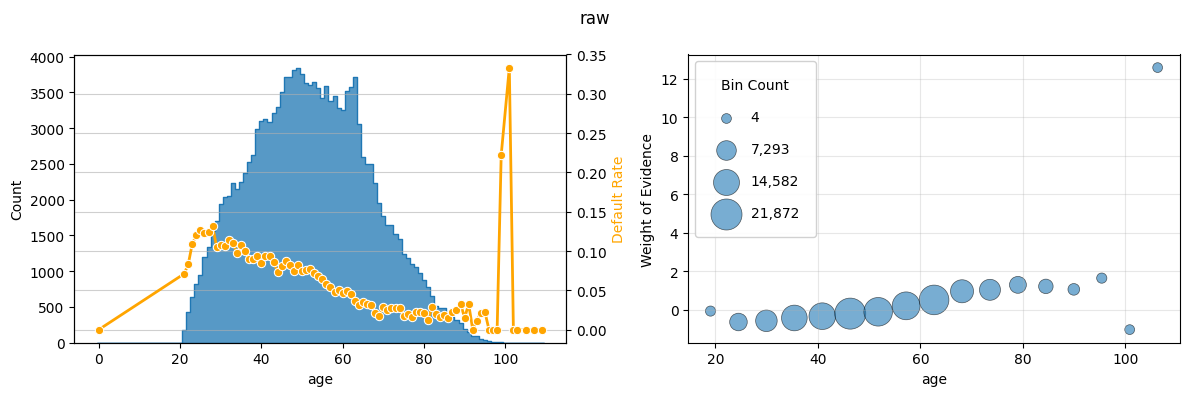

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'age',
                      n_quantiles=40, discrete=True, title='', ax=axs[0])
plot_WoE(train_raw, 'age', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### Continuous Feature Scaling

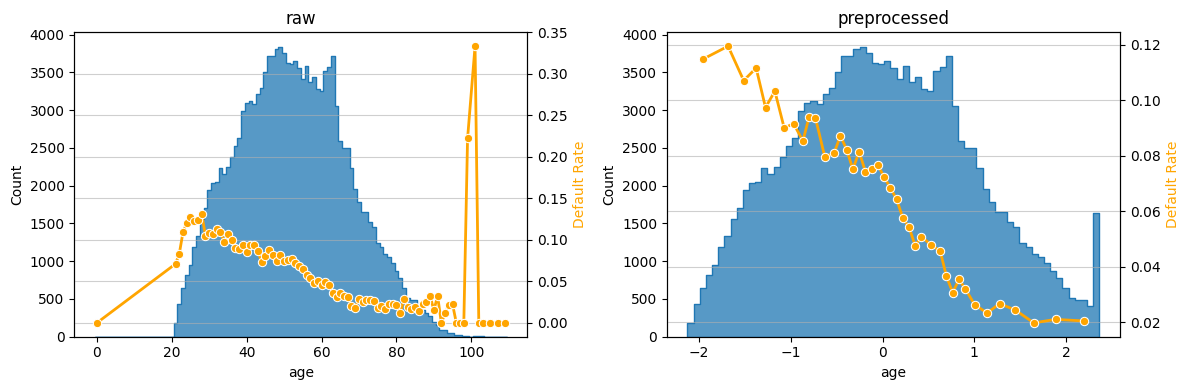

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'age',
                      title=rf'raw', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'age', y, bins=train_processed.age.unique().size,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [78]:
train_processed['age^2'] = scale(train_processed.age ** 2)
train_processed['age^3'] = scale(train_processed.age ** 3)

### WoE Transformation

In [8]:
train_processed['age_woe'], age_binner = apply_woe_binning(
    df=train_raw,
    feature='age',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    monotonic_trend='descending'
)

Feature: age
Binning status: OPTIMAL, N bins: 9
Bins: [29.5 36.5 43.5 52.5 55.5 59.5 62.5 67.5 74.5]



In [82]:
train_woe

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_clipped_young,age_clipped_old,debt_ratio_clipped,debt_income_ratio,is_young,is_senior,utilization_squared,total_delinquencies,has_delinquency
0,-1.350894,-0.589248,-3.186903,-1.105787,0.892491,0.363181,0.242608,-1.183575,0.231085,-1.249825,-0.002582,-0.092626,-0.510863,0.952071,-0.249962,-0.689338,0.947110,0.086041,1.985000
1,-1.850753,-0.792617,0.419152,0.523833,-1.813846,0.050247,0.242608,-1.108284,0.231085,-0.653294,-0.002582,-0.092626,-0.510863,-0.855305,-0.249962,-0.689338,1.827705,-0.074393,-0.503778
2,-0.848742,-0.792617,-1.714465,0.523833,-1.813846,-2.906220,-4.121884,-1.108284,0.231085,0.758760,-0.002582,-0.092626,-0.510863,-0.870257,-0.249962,-0.689338,0.535825,0.086041,1.985000
3,0.089770,-1.100975,0.419152,0.523833,-1.813846,0.092899,0.242608,-1.108284,0.231085,0.758760,-0.002582,-0.092626,-0.510863,-0.906359,-0.249962,-0.689338,-0.476773,-0.074393,-0.503778
4,-1.850753,-0.520784,-1.714465,0.523833,1.538573,0.601114,0.242608,0.992016,0.231085,0.758760,-0.002582,-0.092626,-0.510863,-0.776300,-0.249962,-0.689338,1.578779,0.005824,1.985000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.902661,1.601651,0.419152,0.823788,-1.543183,0.050247,0.242608,0.992016,0.231085,0.758760,-0.002582,-0.092626,-0.510863,-0.815089,-0.249962,1.450666,-0.618584,-0.074393,-0.503778
149996,0.089770,-0.589248,0.419152,-1.105787,0.301783,0.050247,0.242608,0.992016,0.231085,-1.249825,-0.002582,-0.092626,-0.510863,0.095138,-0.249962,-0.689338,-0.382664,-0.074393,-0.503778
149997,0.089770,0.223254,0.419152,-1.105787,0.301783,-0.305180,0.242608,0.992016,0.231085,0.758760,-0.002582,-0.092626,1.957472,1.848960,-0.249962,-0.689338,-0.461069,-0.074393,-0.503778
149998,0.902661,-1.100975,0.419152,0.523833,0.301783,0.050247,0.242608,-1.108284,0.231085,0.758760,-0.002582,-0.092626,-0.510863,-0.937048,-0.249962,-0.689338,-0.623010,-0.074393,-0.503778


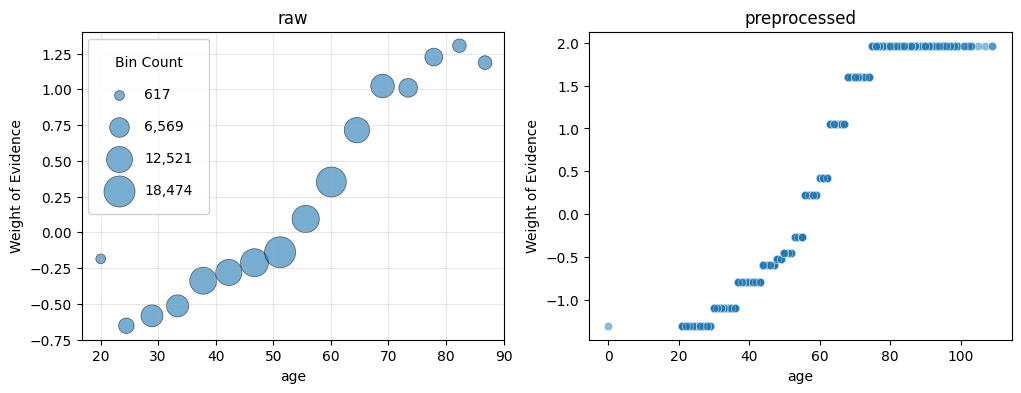

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_WoE(train_raw, 'age', 'SeriousDlqin2yrs', ax=axs[0], title='raw',
         xlabel='age', clip_max=train_raw.age.quantile(0.995));

sns.scatterplot(x=train_raw.age, y=train_woe.age, alpha=0.5);
axs[1].set_ylabel('Weight of Evidence')

axs[1].set_title('preprocessed');

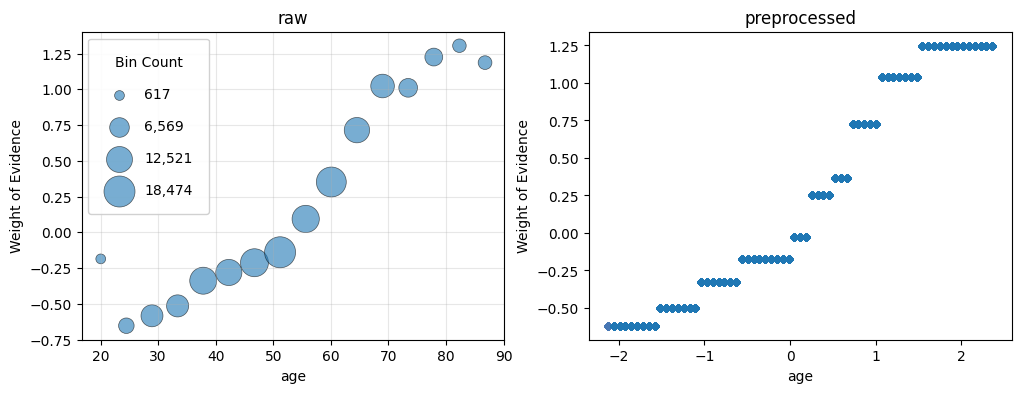

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_WoE(train_raw, 'age', 'SeriousDlqin2yrs', ax=axs[0], title='raw',
         xlabel='age', clip_max=train_raw.age.quantile(0.995));

sns.scatterplot(train_processed, x='age', y='age_woe', alpha=0.005);
axs[1].set_ylabel('Weight of Evidence')

axs[1].set_title('preprocessed');

## `MonthlyIncome`

In [10]:
train_processed['MonthlyIncome_imp'] = train_raw.MonthlyIncome.fillna(0.0)

In [11]:
low_income = train_raw.MonthlyIncome.quantile(0.05)
print(f'Low     income threshold: {low_income:.2f}')

high_income = train_raw.MonthlyIncome.quantile(0.99)
print(f'Extreme income threshold: {high_income:.2f}')

Low     income threshold: 1300.00
Extreme income threshold: 25000.00


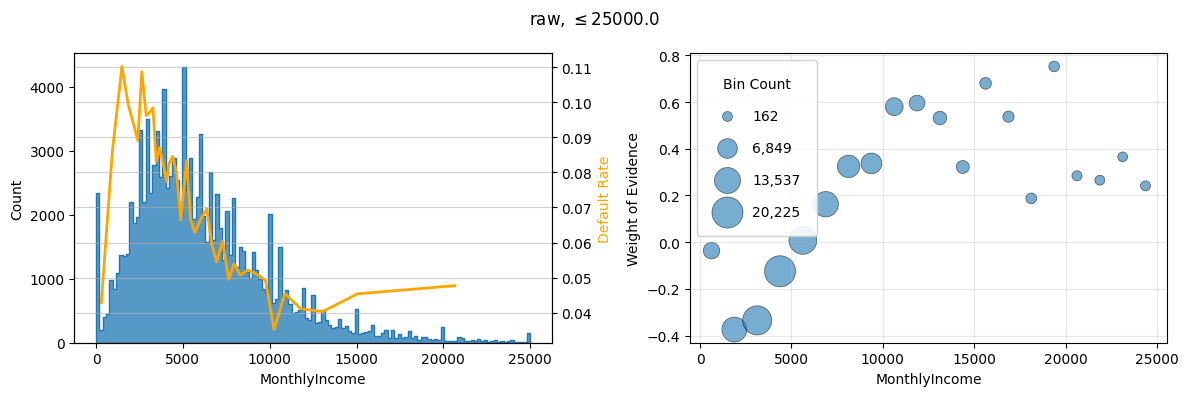

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'MonthlyIncome', max_value=high_income,
                      n_quantiles=40, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.MonthlyIncome.le(high_income)], 'MonthlyIncome', ax=axs[1])

fig.suptitle(fr'raw, $\leq {high_income}$')
plt.tight_layout()

### Continuous Feature Scaling

In [11]:
income_threshold = train_raw.MonthlyIncome.quantile(0.95)

#train_processed.MonthlyIncome = scale(train_raw.MonthlyIncome.fillna(0.0).clip(upper=income_threshold))

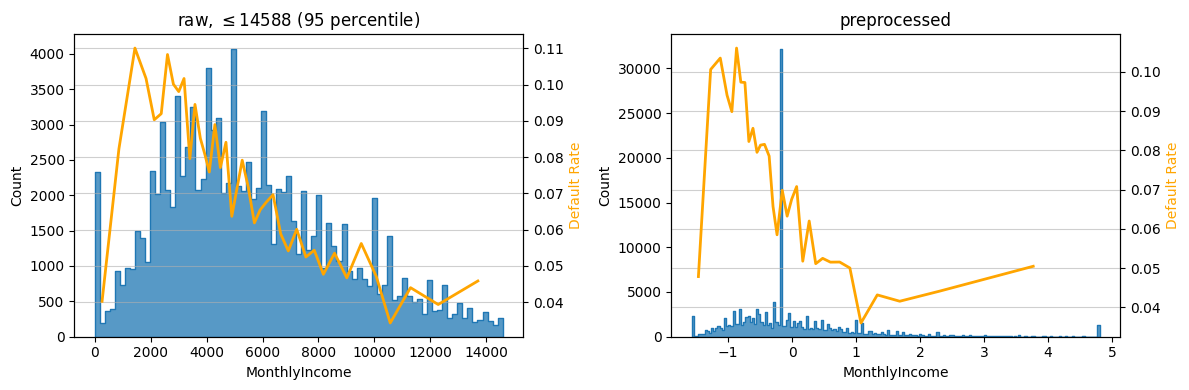

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'MonthlyIncome', max_value=income_threshold,
                      title=rf'raw, $\leq {income_threshold:.0f}$ (95 percentile)', ax=axes[0])
plot_feature_analysis(train_processed, 'MonthlyIncome', y,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

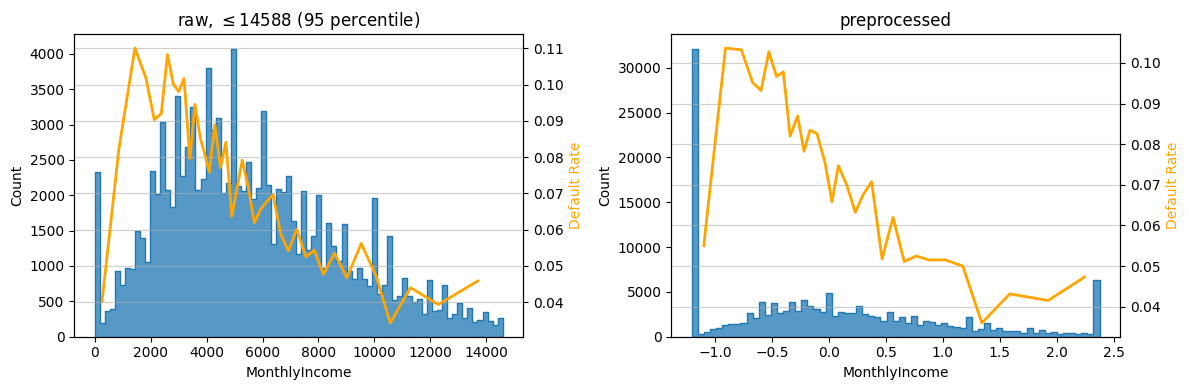

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'MonthlyIncome', max_value=income_threshold,
                      title=rf'raw, $\leq {income_threshold:.0f}$ (95 percentile)', ax=axes[0])
plot_feature_analysis(train_processed, 'MonthlyIncome',
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [15]:
train_processed['MonthlyIncome_missing'] = train_raw.MonthlyIncome.isna().astype(int)
train_processed['MonthlyIncome_zero']    = train_raw.MonthlyIncome.eq(0.0).astype(int)

train_processed['LowIncome']  = train_raw.MonthlyIncome.le(low_income).astype(int)
train_processed['HighIncome'] = train_raw.MonthlyIncome.ge(high_income).astype(int)

### WoE Transformation

In [16]:
train_processed['MonthlyIncome_woe'], income_binner = apply_woe_binning(
    df=train_processed,
    feature='MonthlyIncome_imp',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    monotonic_trend='auto'
)

Feature: MonthlyIncome_imp
Binning status: OPTIMAL, N bins: 8
Bins: [ 930.5 2000.5 3332.5 4833.5 5330.5 6643.5 7656.5 9945.5]



In [17]:
binning_table = income_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 930.50)",34046,0.226973,32175,1871,0.054955,0.208442,9.014962e-03,1.124835e-03
1,"[930.50, 2000.50)",7688,0.051253,6876,812,0.105619,-0.499983,1.593247e-02,1.971070e-03
2,"[2000.50, 3332.50)",16898,0.112653,15240,1658,0.098118,-0.417963,2.361187e-02,2.930187e-03
3,"[3332.50, 4833.50)",22942,0.152947,21046,1896,0.082643,-0.229311,8.886214e-03,1.108349e-03
4,"[4833.50, 5330.50)",7542,0.050280,7007,535,0.070936,-0.063877,2.109189e-04,2.636038e-05
5,"[5330.50, 6643.50)",16066,0.107107,14992,1074,0.066849,-0.000148,2.353920e-09,2.942400e-10
6,"[6643.50, 7656.50)",9903,0.066020,9353,550,0.055539,0.197259,2.359650e-03,2.944790e-04
7,"[7656.50, 9945.50)",14975,0.099833,14207,768,0.051285,0.281425,7.006530e-03,8.729375e-04
8,"[9945.50, inf)",19940,0.132933,19078,862,0.043230,0.460761,2.318562e-02,2.872834e-03
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00


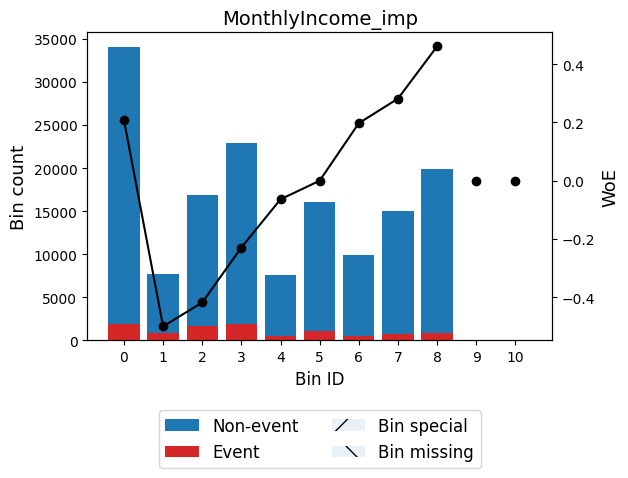

In [18]:
binning_table.plot(figsize=(6, 4))

## `RevolvingUtilizationOfUnsecuredLines`

In [19]:
util_threshold = train_raw.RevolvingUtilizationOfUnsecuredLines.quantile(0.99)
print(f'99 процентиль: {util_threshold}')

util_threshold = 2.0

99 процентиль: 1.0929557681400022


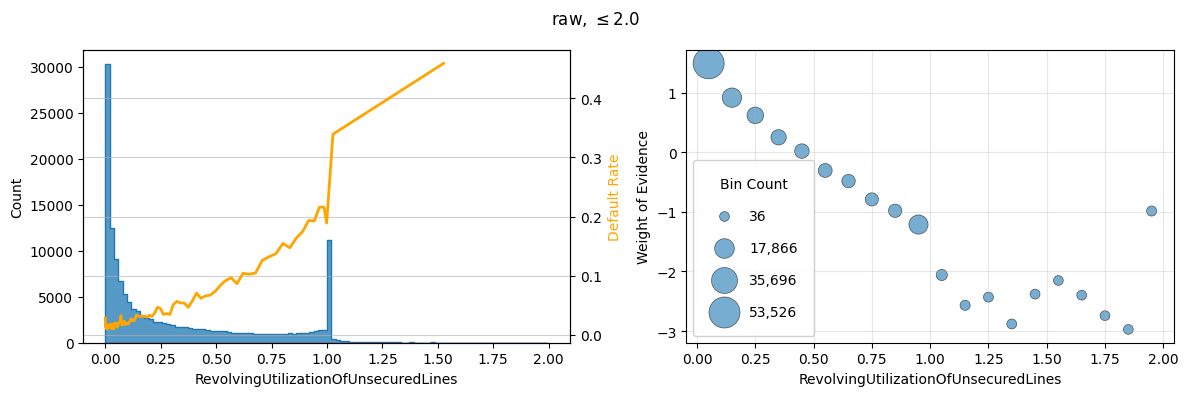

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'RevolvingUtilizationOfUnsecuredLines',
                      n_quantiles=100, max_value=2, title='', ax=axs[0])
plot_WoE(train_raw, 'RevolvingUtilizationOfUnsecuredLines', clip_max=util_threshold, ax=axs[1])

fig.suptitle(fr'raw, $\leq {util_threshold}$')
plt.tight_layout()

### Continuous Feature Scaling

In [21]:
train_processed.RevolvingUtilizationOfUnsecuredLines = train_raw.RevolvingUtilizationOfUnsecuredLines \
                                                      .clip(upper=1.0)

train_processed.RevolvingUtilizationOfUnsecuredLines = scale(train_processed[['RevolvingUtilizationOfUnsecuredLines']])

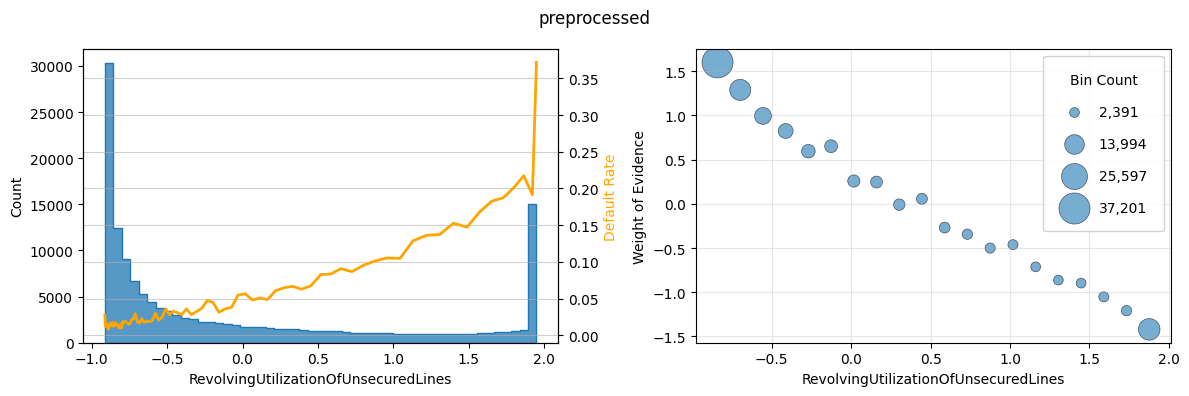

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_processed, 'RevolvingUtilizationOfUnsecuredLines',
                      n_quantiles=100, title='', ax=axs[0])
plot_WoE(train_processed, 'RevolvingUtilizationOfUnsecuredLines', ax=axs[1])

fig.suptitle('preprocessed')
plt.tight_layout()

### New Features

In [23]:
train_processed['RevolvingUtilizationOfUnsecuredLines_is_clipped'] = train_raw.RevolvingUtilizationOfUnsecuredLines \
                                                                    .gt(util_threshold).astype(int)

### WoE Transformation

In [24]:
train_processed['RevolvingUtilizationOfUnsecuredLines_woe'], util_binner = apply_woe_binning(
    df=train_raw,
    feature='RevolvingUtilizationOfUnsecuredLines',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    monotonic_trend='ascending'
)

Feature: RevolvingUtilizationOfUnsecuredLines
Binning status: OPTIMAL, N bins: 8
Bins: [0.05938394 0.13183673 0.21776091 0.30089724 0.38952631 0.49497613
 0.69814232 0.90326244]



In [25]:
binning_table = util_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.06)",52081,0.347207,51173,908,0.017434,1.395448,0.383783,0.044424
1,"[0.06, 0.13)",18962,0.126413,18560,402,0.021200,1.196037,0.110634,0.013060
2,"[0.13, 0.22)",12911,0.086073,12509,402,0.031136,0.801477,0.039489,0.004808
3,"[0.22, 0.30)",9027,0.060180,8676,351,0.038883,0.571255,0.015409,0.001900
4,"[0.30, 0.39)",7769,0.051793,7364,405,0.052130,0.264197,0.003227,0.000402
5,"[0.39, 0.49)",7611,0.050740,7122,489,0.064249,0.042306,0.000089,0.000011
6,"[0.49, 0.70)",11599,0.077327,10499,1100,0.094836,-0.380305,0.013200,0.001640
7,"[0.70, 0.90)",10172,0.067813,8662,1510,0.148447,-0.889439,0.078916,0.009552
8,"[0.90, inf)",19868,0.132453,15409,4459,0.224431,-1.396248,0.467267,0.054083
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


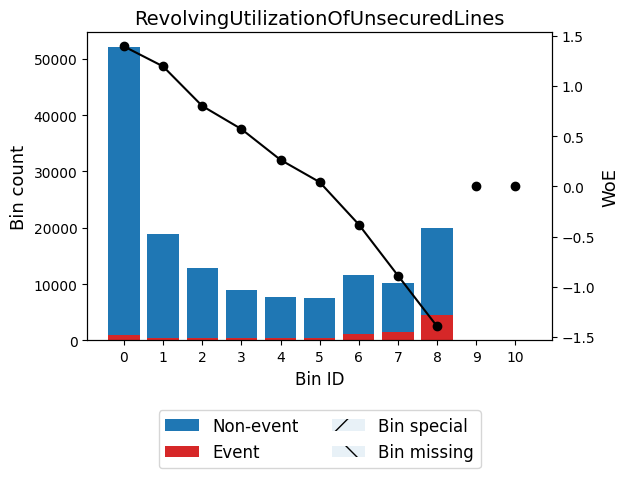

In [26]:
binning_table.plot(figsize=(6, 4))

## `DebtRatio`

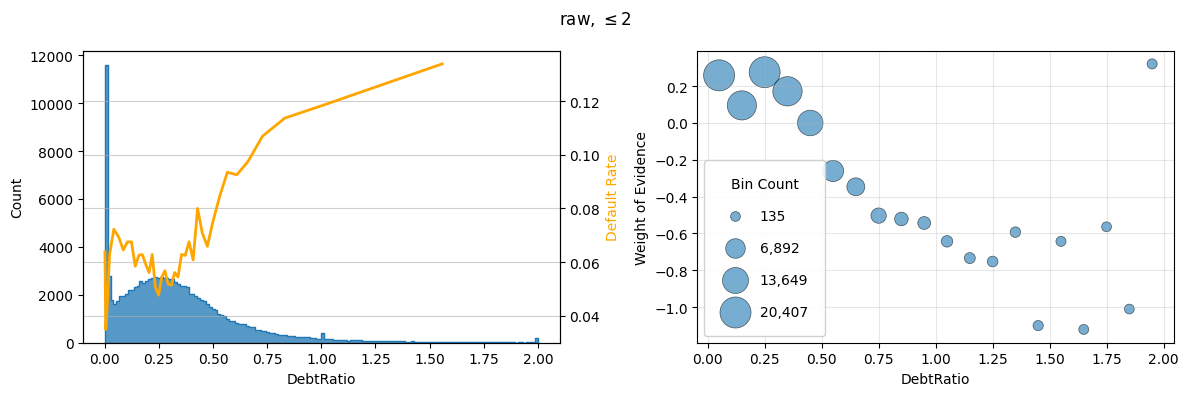

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DebtRatio',
                      max_value=2, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.DebtRatio.le(2)], 'DebtRatio', ax=axs[1])

fig.suptitle(fr'raw, $\leq 2$')
plt.tight_layout()
plt.show()

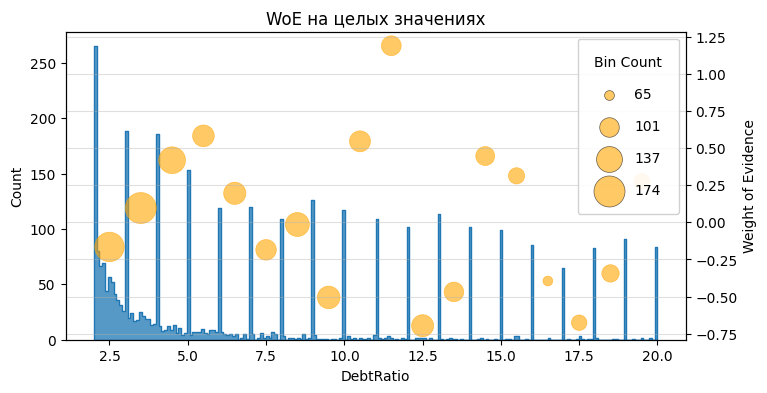

In [28]:
lower = 2
upper = 20

fig, ax1 = plt.subplots(figsize=(8, 4))

sns.histplot(x=train_raw.loc[train_raw.DebtRatio.between(left=lower, right=upper), 'DebtRatio'],
             element='step', ax=ax1, bins=200)

test_whole = train_raw.loc[(train_raw.DebtRatio % 1 == 0) &
                           (train_raw.DebtRatio.between(lower, upper)),
                           ['DebtRatio', 'SeriousDlqin2yrs']].astype(int)

ax2 = ax1.twinx()
plot_WoE(test_whole, 'DebtRatio', 'SeriousDlqin2yrs', edgecolors=None,
         ax=ax2, bins=18, color='orange', title='WoE на целых значениях');

ax2.grid(True, alpha=0.4)

На целых значениях риск тоже не монотонен

### Continuous Feature Scaling

In [29]:
normal_threshold  = 2
extreme_threshold = 4

normal_median = train_raw.loc[train_raw.DebtRatio.le(normal_threshold), 'DebtRatio'].median()
DebtRatio_clipped = train_raw[['DebtRatio']].where(train_raw.DebtRatio.le(normal_threshold),
                                              normal_median).clip(upper=normal_threshold)

train_processed.DebtRatio = power_transform(DebtRatio_clipped, method='yeo-johnson')

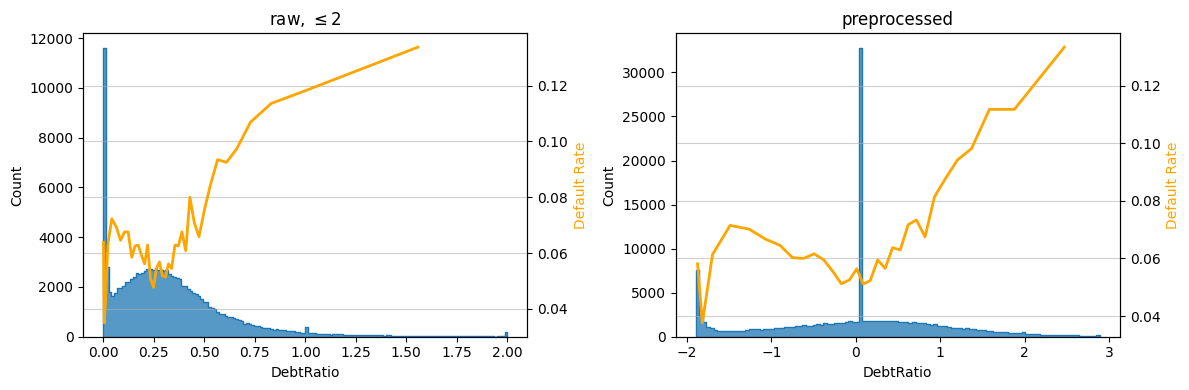

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DebtRatio', max_value=2,
                      title=rf'raw, $\leq {2}$', ax=axes[0])
plot_feature_analysis(train_processed, 'DebtRatio',
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [31]:
train_processed['DebtRatio^2'] = scale(train_processed.DebtRatio ** 2)
train_processed['DebtRatio^3'] = scale(train_processed.DebtRatio ** 3)

train_processed['DebtRatio_normal']  = train_raw.DebtRatio.le(normal_threshold).astype(int)
train_processed['DebtRatio_extreme'] = train_raw.DebtRatio.gt(extreme_threshold).astype(int)

train_processed['DebtRatio_zero']  = train_raw.DebtRatio.eq(0.0).astype(int)
train_processed['DebtRatio_whole'] = ((np.isclose(train_raw.DebtRatio % 1, 0, atol=1e-9)) &
                                    (train_raw.DebtRatio.gt(0))).astype(int)

### WoE Transformation

In [32]:
train_processed['DebtRatio_woe'], debt_binner = apply_woe_binning(
    df=train_raw,
    feature='DebtRatio',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
   special_codes={'zero': 0},
)

Feature: DebtRatio
Binning status: OPTIMAL, N bins: 7
Bins: [  0.01634838   0.34570184   0.42332079   0.50549355   0.65367481
   3.97284353 995.5       ]



In [33]:
binning_table = debt_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.02)",8296,0.055307,8009,287,0.034595,0.692564,0.019802,0.002427
1,"[0.02, 0.35)",58882,0.392547,55367,3515,0.059696,0.120669,0.005426,0.000678
2,"[0.35, 0.42)",12807,0.085380,11996,811,0.063325,0.057786,0.000278,0.000035
3,"[0.42, 0.51)",10183,0.067887,9444,739,0.072572,-0.088438,0.000552,0.000069
4,"[0.51, 0.65)",10998,0.073320,10009,989,0.089925,-0.321729,0.008731,0.001087
5,"[0.65, 3.97)",14652,0.097680,12965,1687,0.115138,-0.596973,0.045154,0.005562
6,"[3.97, 995.50)",13144,0.087627,12316,828,0.062995,0.063366,0.000342,0.000043
7,"[995.50, inf)",16925,0.112833,16095,830,0.049040,0.328563,0.010580,0.001317
8,zero,4113,0.027420,3773,340,0.082665,-0.229595,0.001597,0.000199
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


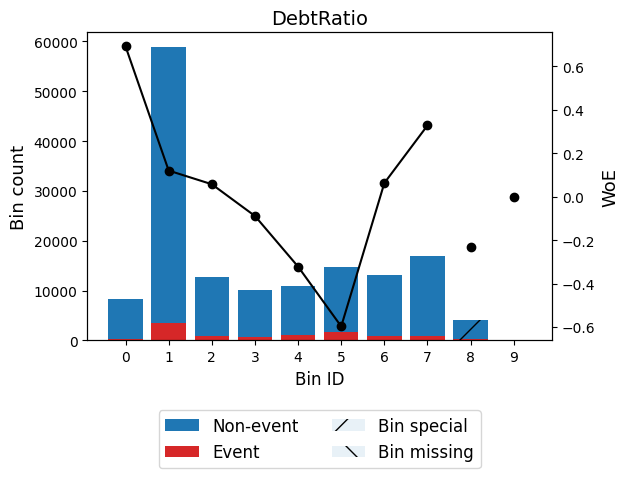

In [34]:
binning_table.plot(figsize=(6, 4))

## `NumberOfDependents`

In [35]:
train_processed['NumberOfDependents_imp'] = train_raw.NumberOfDependents.fillna(0.0)

In [36]:
many_threshold = train_raw.NumberOfDependents.quantile(0.975)
print(f'97.5 процентиль: {many_threshold}')

97.5 процентиль: 4.0


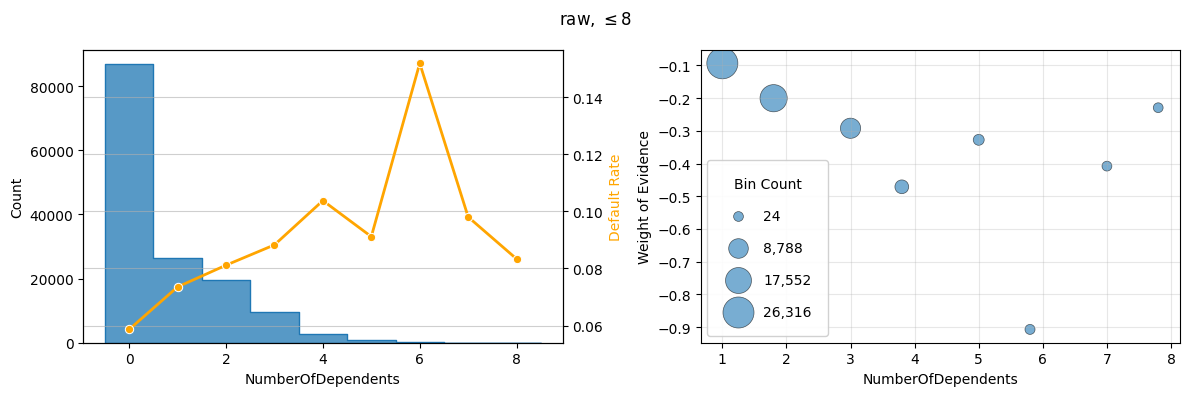

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfDependents', discrete=True,
                      max_value=8, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.NumberOfDependents.le(8)], 'NumberOfDependents', ax=axs[1])

fig.suptitle(fr'raw, $\leq 8$')
plt.tight_layout()

### New Features

In [38]:
train_processed['NumberOfDependents_missing'] = train_raw.NumberOfDependents.isna().astype(int)

### Continuous Feature Scaling

In [39]:
train_processed.NumberOfDependents = train_processed.NumberOfDependents_imp.copy()

train_processed.NumberOfDependents = scale(train_raw.NumberOfDependents.clip(upper=many_threshold))

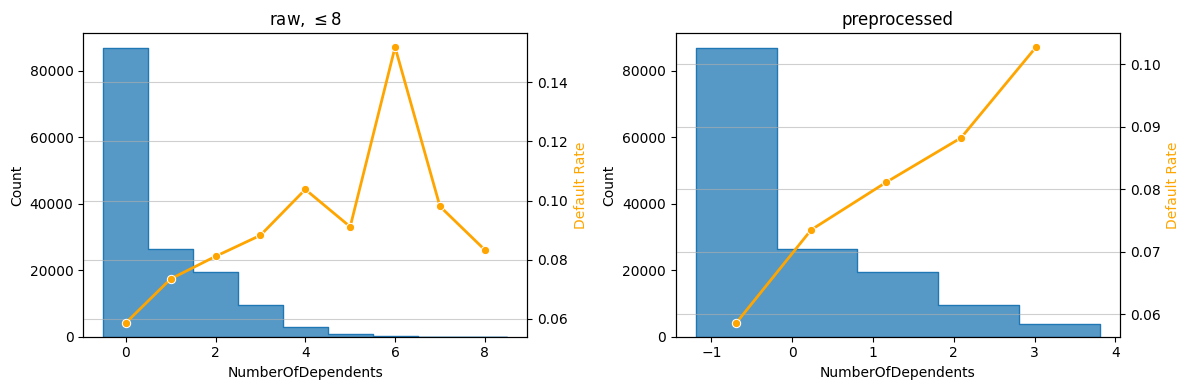

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfDependents', max_value=8,
                      title=rf'raw, $\leq 8$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfDependents', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()
plt.show()

### WoE Transformation

In [41]:
train_processed['NumberOfDependents_woe'], deps_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfDependents',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    min_prebin_size=0.02,
    monotonic_trend='ascending'
)

Feature: NumberOfDependents
Binning status: OPTIMAL, N bins: 4
Bins: [0.5 1.5 2.5 3.5]



In [42]:
binning_table = deps_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",86902,0.579347,81807,5095,0.058629,0.139828,0.010664,0.001332
1,"[0.50, 1.50)",26316,0.175440,24381,1935,0.073529,-0.102578,0.001930,0.000241
2,"[1.50, 2.50)",19522,0.130147,17938,1584,0.081139,-0.209307,0.006245,0.000779
3,"[2.50, 3.50)",9483,0.063220,8646,837,0.088263,-0.301247,0.006541,0.000815
4,"[3.50, inf)",3853,0.025687,3457,396,0.102777,-0.469533,0.006949,0.000861
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,3924,0.026160,3745,179,0.045617,0.404516,0.003601,0.000447
Totals,,150000,1.000000,139974,10026,0.066840,,0.035930,0.004475


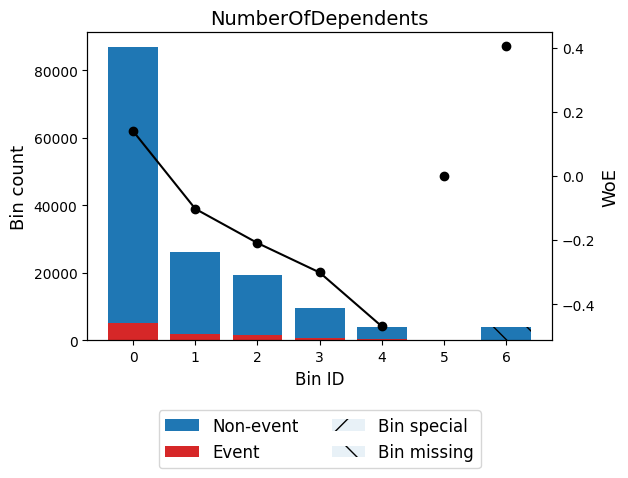

In [43]:
binning_table.plot(figsize=(6, 4))

## `NumberOfOpenCreditLinesAndLoans`

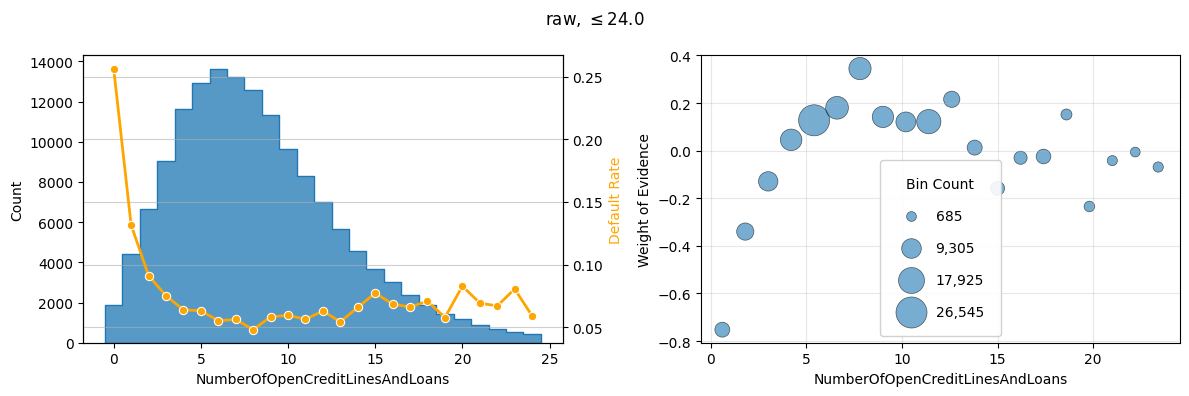

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

many_loans = train_raw.NumberOfOpenCreditLinesAndLoans.quantile(0.99)

plot_feature_analysis(train_raw, 'NumberOfOpenCreditLinesAndLoans', discrete=True,
                      max_value=many_loans, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.NumberOfOpenCreditLinesAndLoans.le(many_loans)], 'NumberOfOpenCreditLinesAndLoans', ax=axs[1])

fig.suptitle(fr'raw, $\leq {many_loans}$')
plt.tight_layout()

### Continuous Feature Scaling

In [45]:
train_processed.NumberOfOpenCreditLinesAndLoans = scale(np.log1p(train_raw.NumberOfOpenCreditLinesAndLoans
                                                                .clip(upper=many_loans)))

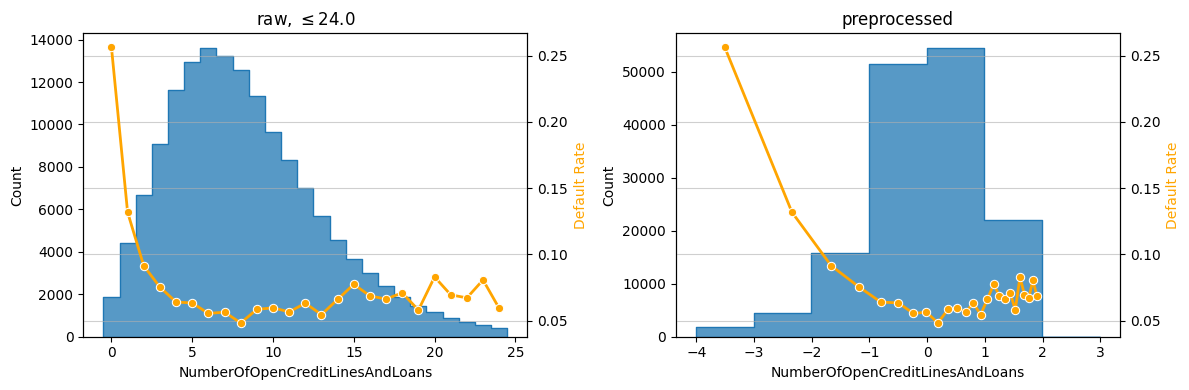

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfOpenCreditLinesAndLoans', max_value=many_loans,
                      title=rf'raw, $\leq {many_loans}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfOpenCreditLinesAndLoans', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [47]:
train_processed['NumberOfOpenCreditLinesAndLoans^2'] = scale(train_processed.NumberOfOpenCreditLinesAndLoans ** 2)

### WoE Transformation

In [48]:
train_processed['NumberOfOpenCreditLinesAndLoans_woe'], loans_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfOpenCreditLinesAndLoans',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    monotonic_trend='descending'
)

Feature: NumberOfOpenCreditLinesAndLoans
Binning status: OPTIMAL, N bins: 4
Bins: [2.5 3.5 4.5 5.5]



In [49]:
binning_table = loans_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",12992,0.086613,11314,1678,0.129156,-0.727837,0.062984,0.007704
1,"[2.50, 3.50)",9058,0.060387,8376,682,0.075293,-0.128179,0.001049,0.000131
2,"[3.50, 4.50)",11609,0.077393,10866,743,0.064002,0.046423,0.000163,0.000020
3,"[4.50, 5.50)",12931,0.086207,12112,819,0.063336,0.057593,0.000279,0.000035
4,"[5.50, inf)",103410,0.689400,97306,6104,0.059027,0.132641,0.011454,0.001431
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.075929,0.009321


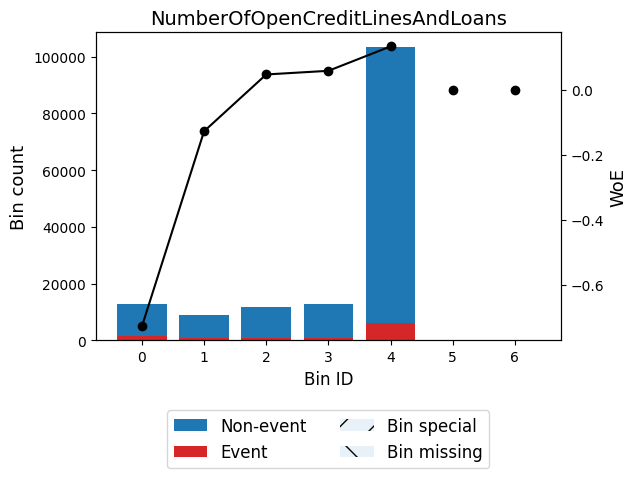

In [50]:
binning_table.plot(figsize=(6, 4))

## `NumberRealEstateLoansOrLines`

In [51]:
many_estate = train_raw.NumberRealEstateLoansOrLines.quantile(0.99)
print(f'99 процентиль: {many_estate}')

99 процентиль: 4.0


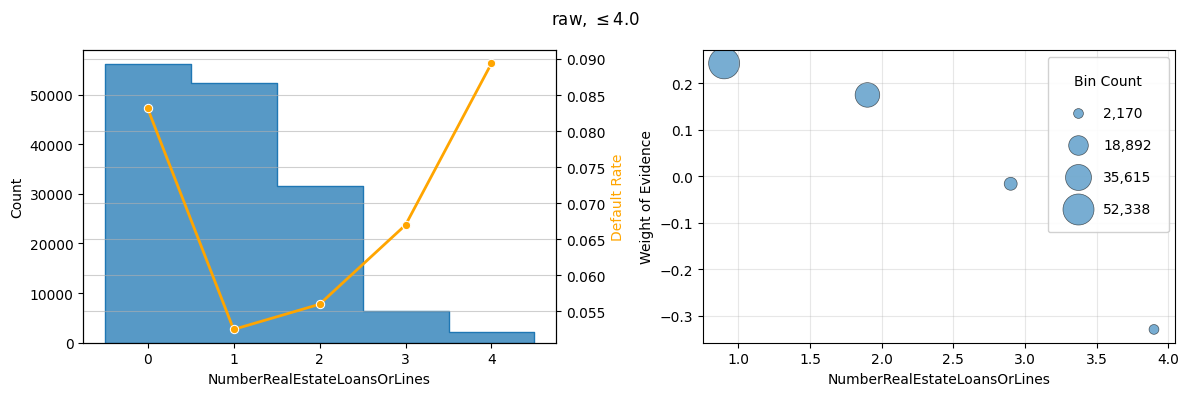

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberRealEstateLoansOrLines', discrete=True,
                      max_value=many_estate, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.NumberRealEstateLoansOrLines.le(many_estate)], 'NumberRealEstateLoansOrLines', ax=axs[1])

fig.suptitle(fr'raw, $\leq {many_estate}$')
plt.tight_layout()

### Continuous Feature Scaling

In [53]:
train_processed.NumberRealEstateLoansOrLines = scale(np.log1p(train_raw.NumberRealEstateLoansOrLines.clip(upper=many_estate)))

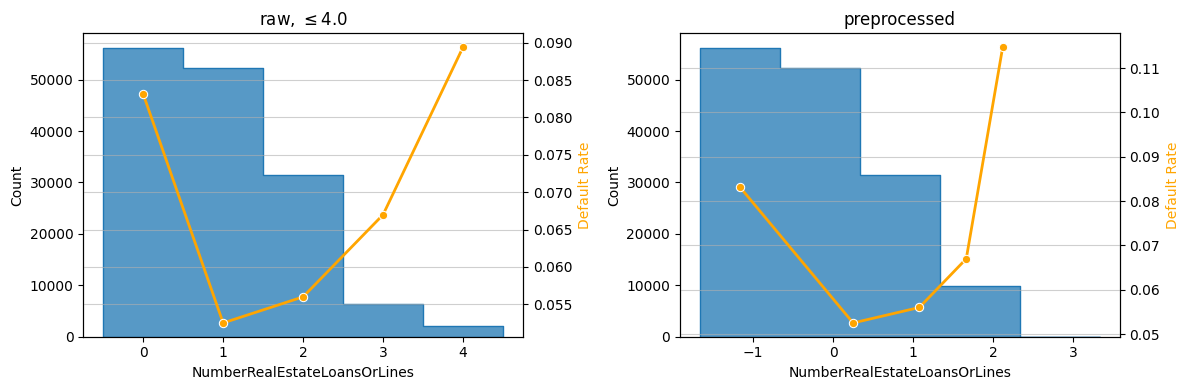

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberRealEstateLoansOrLines', max_value=many_estate,
                      title=rf'raw, $\leq {many_estate}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberRealEstateLoansOrLines', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [55]:
train_processed['NumberRealEstateLoansOrLines^2'] = scale(train_processed.NumberRealEstateLoansOrLines ** 2)

### WoE Transformation

In [56]:
train_processed['NumberRealEstateLoansOrLines_woe'], estate_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberRealEstateLoansOrLines',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    monotonic_trend='auto'
)

Feature: NumberRealEstateLoansOrLines
Binning status: OPTIMAL, N bins: 3
Bins: [0.5 1.5 2.5]



In [57]:
binning_table = estate_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",56188,0.374587,51516,4672,0.083149,-0.23597,0.023113,0.002882
1,"[0.50, 1.50)",52338,0.348920,49590,2748,0.052505,0.256641,0.020581,0.002566
2,"[1.50, 2.50)",31522,0.210147,29757,1765,0.055993,0.188639,0.006894,0.000861
3,"[2.50, inf)",9952,0.066347,9111,841,0.084506,-0.253629,0.004766,0.000594
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.055354,0.006903


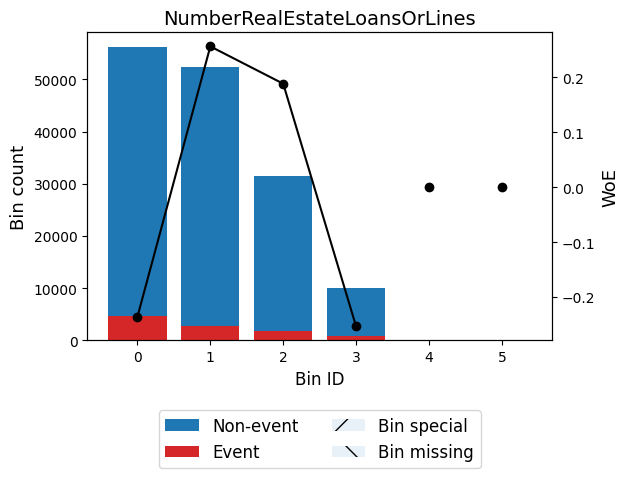

In [58]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTime30-59DaysPastDueNotWorse`

In [59]:
many_pd30_59 = train_raw['NumberOfTime30-59DaysPastDueNotWorse'].quantile(0.99)
print(f'99 процентиль: {many_pd30_59}')

99 процентиль: 4.0


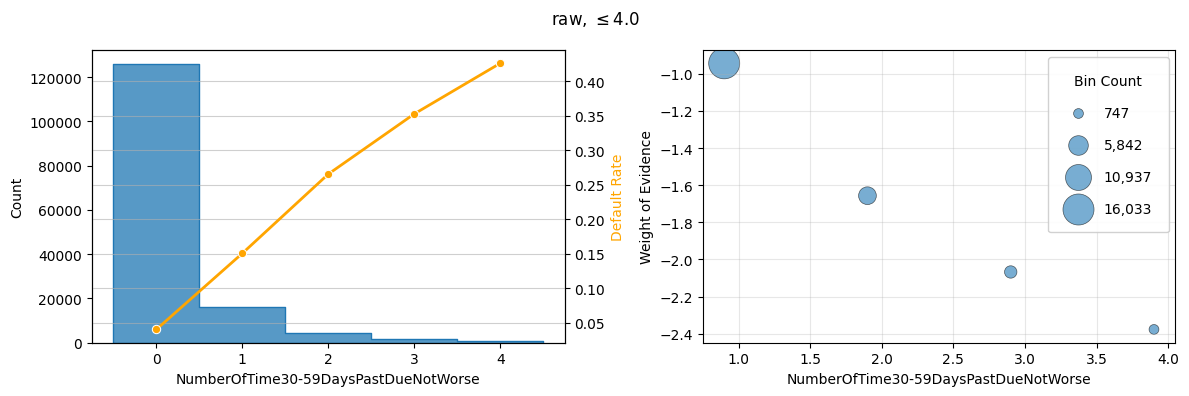

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime30-59DaysPastDueNotWorse', discrete=True,
                      max_value=many_pd30_59, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw['NumberOfTime30-59DaysPastDueNotWorse'].le(many_pd30_59)],
         'NumberOfTime30-59DaysPastDueNotWorse', ax=axs[1])

fig.suptitle(fr'raw, $\leq {many_pd30_59}$')
plt.tight_layout()

### Continuous Feature Scaling

In [61]:
train_processed['NumberOfTime30-59DaysPastDueNotWorse'] = scale(train_raw['NumberOfTime30-59DaysPastDueNotWorse'] \
                                                                               .clip(upper=many_pd30_59))

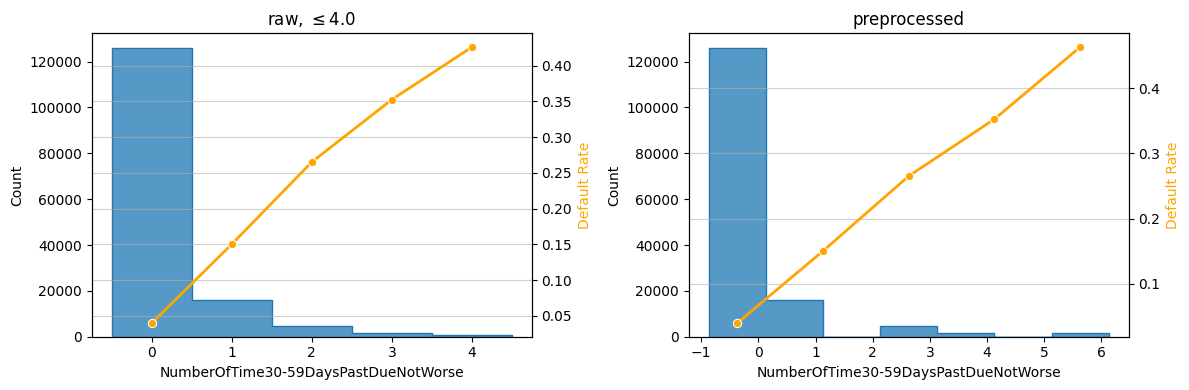

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime30-59DaysPastDueNotWorse', max_value=many_pd30_59,
                      title=rf'raw, $\leq {many_pd30_59}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTime30-59DaysPastDueNotWorse', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### WoE Transformation

In [63]:
train_processed['NumberOfTime30-59DaysPastDueNotWorse_woe'], pd30_59_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTime30-59DaysPastDueNotWorse',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    min_prebin_size=0.005,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTime30-59DaysPastDueNotWorse
Binning status: OPTIMAL, N bins: 4
Bins: [0.5 1.5 2.5 3.5]



In [64]:
binning_table = pd30_59_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",126018,0.840120,120977,5041,0.040002,0.541721,0.195826,0.024183
1,"[0.50, 1.50)",16033,0.106887,13624,2409,0.150253,-0.903654,0.129171,0.015618
2,"[1.50, 2.50)",4598,0.030653,3379,1219,0.265115,-1.616726,0.157540,0.017794
3,"[2.50, 3.50)",1754,0.011693,1136,618,0.352338,-2.027495,0.108520,0.011634
4,"[3.50, inf)",1328,0.008853,736,592,0.445783,-2.418551,0.130090,0.013185
5,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
6,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.760283,0.086124


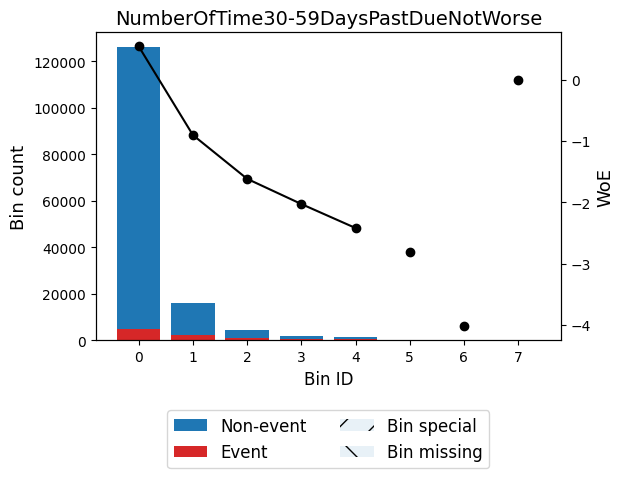

In [65]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTime60-89DaysPastDueNotWorse`

In [66]:
many_pd60_89 = train_raw['NumberOfTime60-89DaysPastDueNotWorse'].quantile(0.99)
print(f'99 процентиль: {many_pd60_89}')

99 процентиль: 2.0


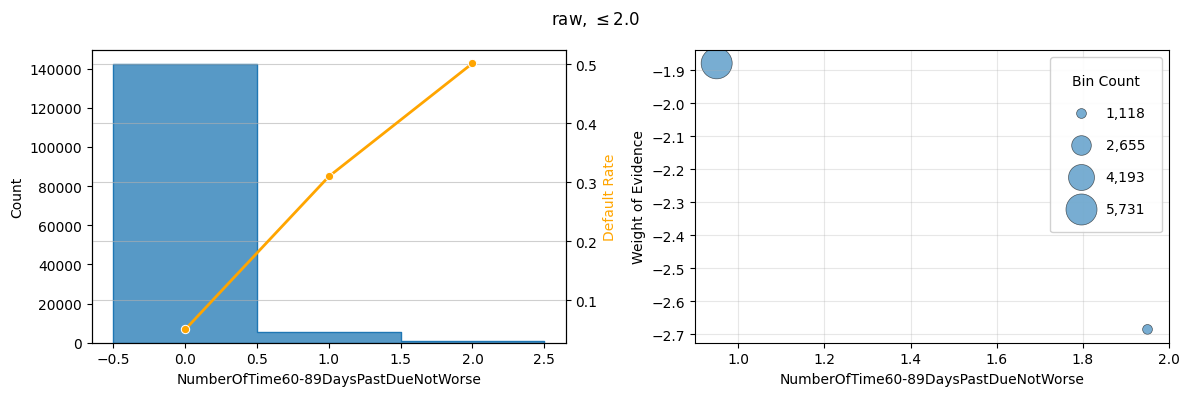

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime60-89DaysPastDueNotWorse', discrete=True,
                      max_value=many_pd60_89, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw['NumberOfTime60-89DaysPastDueNotWorse'].le(many_pd60_89)],
         'NumberOfTime60-89DaysPastDueNotWorse', ax=axs[1])

fig.suptitle(fr'raw, $\leq {many_pd60_89}$')
plt.tight_layout()

### Continuous Feature Scaling

In [68]:
train_processed['NumberOfTime60-89DaysPastDueNotWorse'] = scale(train_raw['NumberOfTime60-89DaysPastDueNotWorse'] \
                                                                               .clip(upper=many_pd60_89))

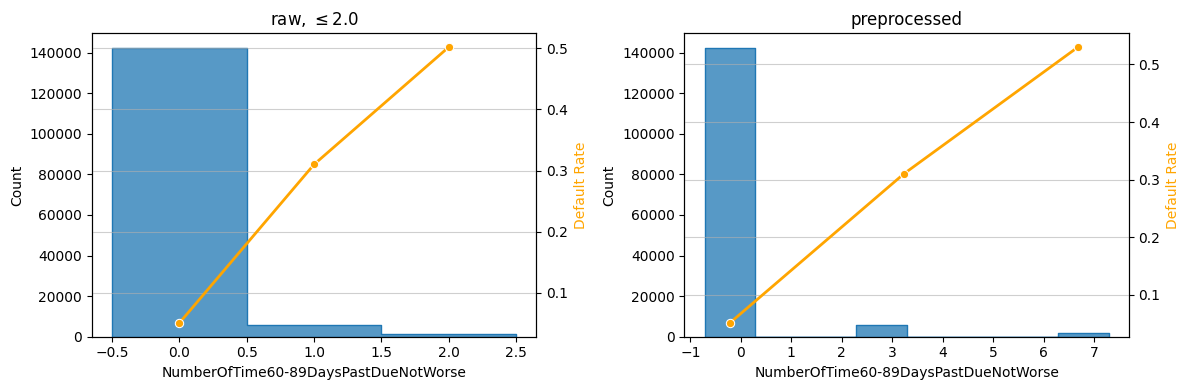

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime60-89DaysPastDueNotWorse', max_value=many_pd60_89,
                      title=rf'raw, $\leq {many_pd60_89}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTime60-89DaysPastDueNotWorse', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### WoE Transformation

In [70]:
train_processed['NumberOfTime60-89DaysPastDueNotWorse_woe'], pd60_89_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTime60-89DaysPastDueNotWorse',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    min_prebin_size=0.01,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTime60-89DaysPastDueNotWorse
Binning status: OPTIMAL, N bins: 2
Bins: [0.5 1.5]



In [71]:
binning_table = pd60_89_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",142396,0.949307,135140,7256,0.050956,0.288208,0.069673,0.008679
1,"[0.50, 1.50)",5731,0.038207,3954,1777,0.310068,-1.836474,0.273618,0.030084
2,"[1.50, inf)",1604,0.010693,758,846,0.527431,-2.746111,0.216848,0.020893
3,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
4,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.599275,0.063364


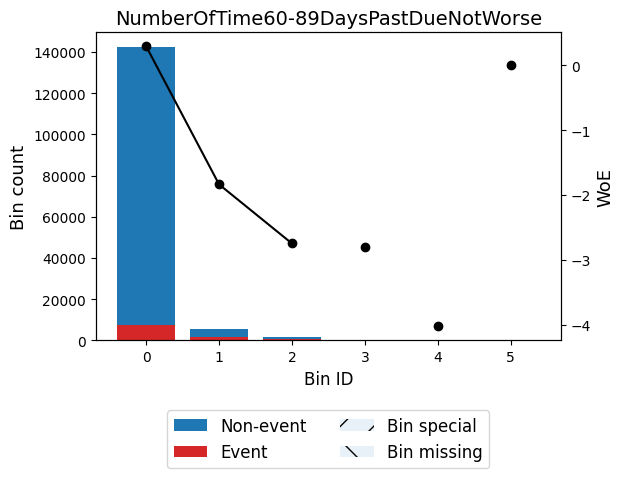

In [72]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTimes90DaysLate`

In [73]:
many_pd90 = train_raw['NumberOfTimes90DaysLate'].quantile(0.99)
print(f'99 процентиль: {many_pd90}')

99 процентиль: 3.0


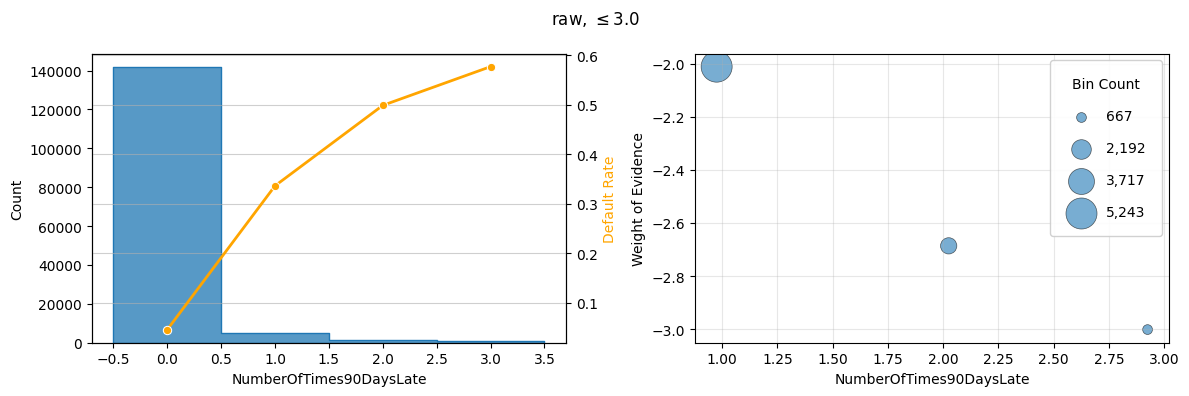

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTimes90DaysLate', discrete=True,
                      max_value=many_pd90, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw['NumberOfTimes90DaysLate'].le(many_pd90)],
         'NumberOfTimes90DaysLate', ax=axs[1])

fig.suptitle(fr'raw, $\leq {many_pd90}$')
plt.tight_layout()

### Continuous Feature Scaling

In [75]:
train_processed['NumberOfTimes90DaysLate'] = scale(np.log1p(train_raw['NumberOfTimes90DaysLate'] \
                                                                .clip(upper=many_pd90)))

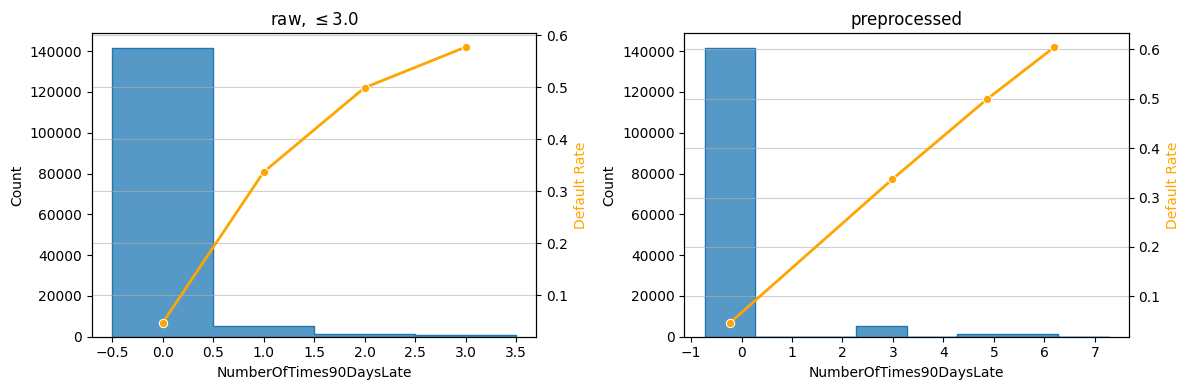

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTimes90DaysLate', max_value=many_pd90,
                      title=rf'raw, $\leq {many_pd90}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTimes90DaysLate', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [77]:
d30 = train_raw["NumberOfTime30-59DaysPastDueNotWorse"]
d60 = train_raw["NumberOfTime60-89DaysPastDueNotWorse"]
d90 = train_raw["NumberOfTimes90DaysLate"]

train_raw["AnyDlq"]      = ((d30 + d60 + d90) > 0).astype(int)
train_raw["DlqCount"]    = (d30 + d60 + d90)
train_raw["DlqWeighted"] = (1*d30 + 2*d60 + 3*d90)

### WoE Transformation

In [78]:
train_processed['NumberOfTimes90DaysLate_woe'], pd90_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTimes90DaysLate',
    target=train_raw.SeriousDlqin2yrs,
    max_n_bins=10,
    min_prebin_size=0.005,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTimes90DaysLate
Binning status: OPTIMAL, N bins: 3
Bins: [0.5 1.5 2.5]



In [79]:
binning_table = pd90_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",141662,0.944413,135108,6554,0.046265,0.389724,0.121413,0.015081
1,"[0.50, 1.50)",5243,0.034953,3478,1765,0.336639,-1.957968,0.296035,0.032036
2,"[1.50, 2.50)",1555,0.010367,779,776,0.499035,-2.632416,0.189096,0.018548
3,"[2.50, inf)",1271,0.008473,487,784,0.616837,-3.11242,0.232552,0.021115
4,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
5,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.878232,0.090488


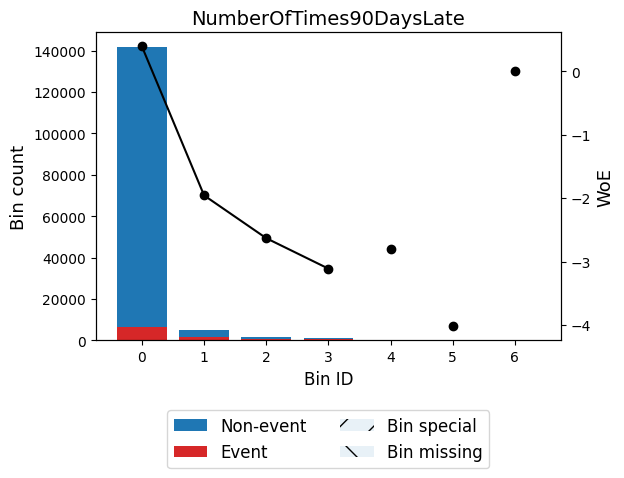

In [80]:
binning_table.plot(figsize=(6, 4))

## `DlqCount`

In [81]:
many_dl = train_raw['DlqCount'].quantile(0.99)
print(f'99 процентиль: {many_dl}')

99 процентиль: 6.0


### Continuous Feature Scaling

In [82]:
train_processed['DlqCount'] = scale(train_raw['DlqCount'].clip(upper=many_dl))

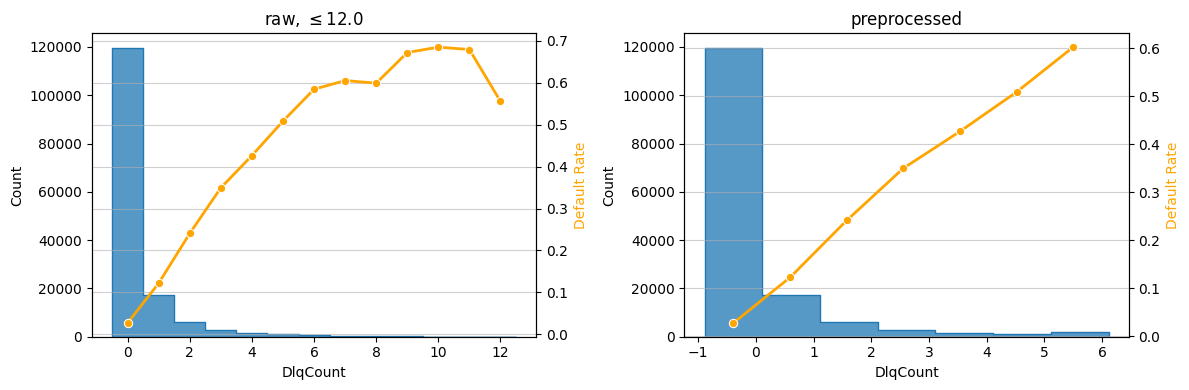

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DlqCount', max_value=many_dl*2,
                      title=rf'raw, $\leq {many_dl*2}$', discrete=True, ax=axes[0])

plot_feature_analysis(train_processed, 'DlqCount', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

## `DlqWeighted`

In [84]:
many_dlw = train_raw['DlqWeighted'].quantile(0.99)
print(f'99 процентиль: {many_dlw}')

99 процентиль: 11.0


### Continuous Feature Scaling

In [85]:
train_processed['DlqWeighted'] = scale(train_raw['DlqWeighted'].clip(upper=many_dlw))

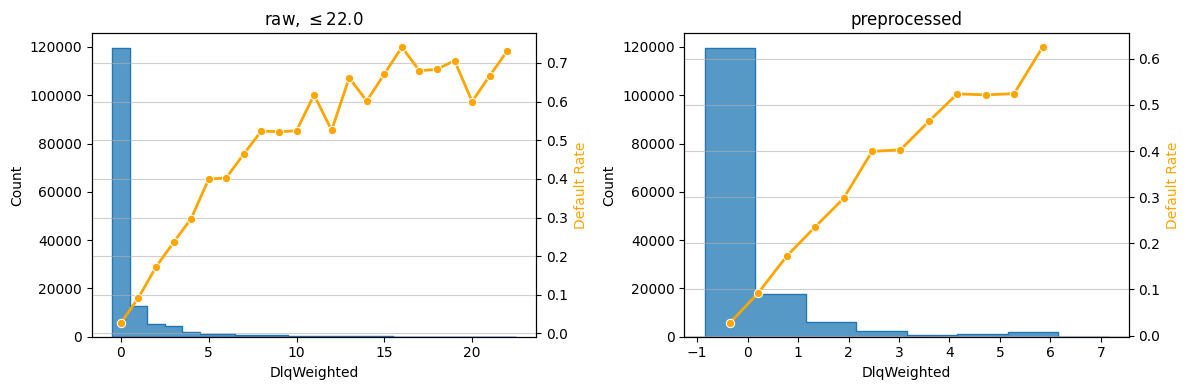

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DlqWeighted', max_value=many_dlw*2,
                      title=rf'raw, $\leq {many_dlw*2}$', discrete=True, ax=axes[0])

plot_feature_analysis(train_processed, 'DlqWeighted', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

In [87]:
pd.set_option('display.max_columns', None)
print(train_processed.describe())

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines           age  \
count     150000.000000                          1.500000e+05  1.500000e+05   
mean           0.066840                          8.981260e-17 -1.466560e-16   
std            0.249746                          1.000003e+00  1.000003e+00   
min            0.000000                         -9.133445e-01 -2.127567e+00   
25%            0.000000                         -8.278820e-01 -7.666002e-01   
50%            0.000000                         -4.721729e-01 -1.806820e-02   
75%            0.000000                          6.863061e-01  7.304638e-01   
max            1.000000                          1.948048e+00  2.363624e+00   

       NumberOfTime30-59DaysPastDueNotWorse     DebtRatio  MonthlyIncome  \
count                          1.500000e+05  1.500000e+05   1.500000e+05   
mean                          -1.061077e-17 -1.100868e-16  -8.621252e-18   
std                            1.000003e+00  1.000003e+00   